# Compte-Rendu de TP : Équations Différentielles Ordinaires et Résolution Numérique

## Introduction

Ce compte-rendu a été réalisé dans le cadre de ma Licence Double-Diplôme Mathématiques et Économie à l'Université Paris-Saclay. Il s'agit d'un compte-rendu de synthèse des méthodes numériques explorées lors des 3 séances de Travaux Pratiques de l'UE, ainsi que le TP noté d'épidémiologie sur lequel j'ai travaillé.

Notes obtenues pour l'UE Equations différentielles ordinaires et résolution numérique :
- **Note au TP noté : 19,5/20**
- **Note finale de l'UE : 17/20**

## TP 1 : Champs de vecteurs et courbes

L'étude d'un champ de vecteurs est importante pour visualiser géométriquement et comprendre le comportement des solutions d'un système différentiel. Cela permet d'identifier l'allure des trajectoires sans nécessairement disposer de l'expression analytique exacte de la solution

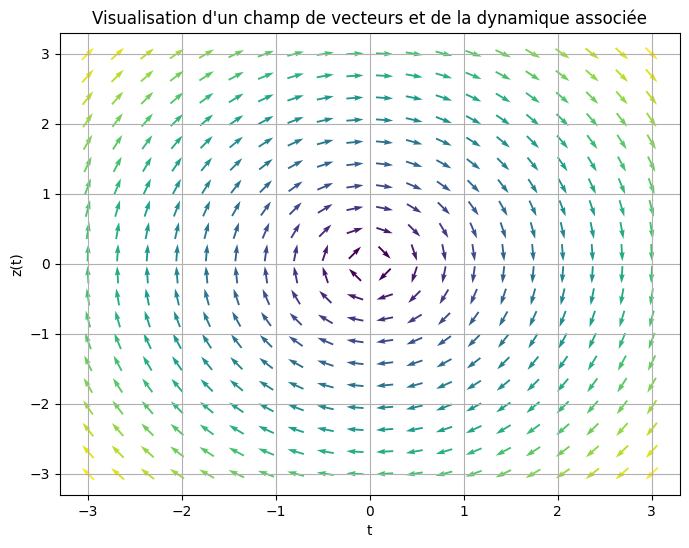

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# grille
t = np.linspace(-3, 3, 20)
y = np.linspace(-3, 3, 20)
T,Y = np.meshgrid(t, y)

#Champ de vecteurs illustrant des trajectoires périodiques
U = Y
V = -T

# Normalisation du champ pour un affichage uniforme et clair
norm = np.sqrt(U**2 + V**2)
U_n = U / norm
V_n = V / norm
plt.figure(figsize=(8, 6))
plt.quiver(T, Y, U_n, V_n, norm, cmap='viridis', pivot='mid')
plt.title("Visualisation d'un champ de vecteurs et de la dynamique associée")
plt.xlabel("t")
plt.ylabel("z(t)")
plt.grid(True)
plt.show()

## TP 2 : Oscillateur harmonique et schéma d'Euler Symplectique

Le schéma d'Euler Symplectique est la meilleure méthode pour simuler des systèmes comme l'oscillateur harmonique. Si on utilise l'approche classique (Euler explicite), le modèle crée artificiellement de l'énergie à chaque pas de temps, ce qui fait que les courbes finissent vite par exploser et partir dans tous les sens. À l'inverse, l'Euler Symplectique arrive à conserver une "énergie modifiée" qui reste proche de l'énergie réelle. La simulation reste stable sur le long terme et les trajectoires du système gardent bien leur forme géométrique de base

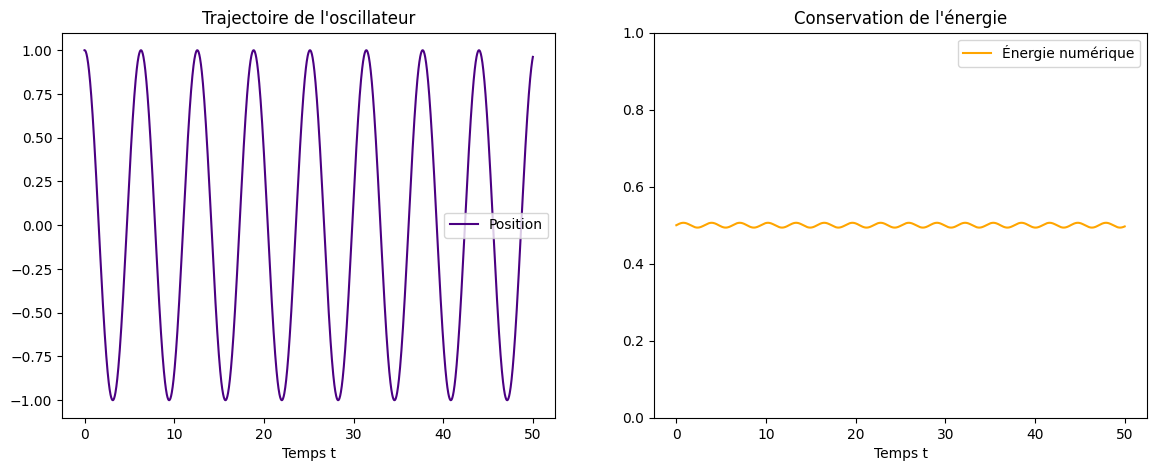

In [16]:
#Schéma d'Euler symplectique
def euler_symplectique(t0, tf, X0, N, omega=1.0):
    t = np.linspace(t0, tf, N)
    h = t[1] - t[0]
    Y = np.zeros((N, 2))
    Y[0] = X0
    for n in range(N - 1):
        Y[n+1, 0] = Y[n, 0] + h * Y[n, 1]
        Y[n+1, 1] = Y[n, 1] - h * (omega**2) * Y[n+1, 0]
    return t, Y

t, Y_sol = euler_symplectique(0, 50, np.array([1.0, 0.0]), 2000)
energie = 0.5 * Y_sol[:, 1]**2 + 0.5 * Y_sol[:, 0]**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(t, Y_sol[:, 0], color='indigo', label='Position')
axes[0].set_title('Trajectoire de l\'oscillateur')
axes[0].set_xlabel('Temps t')
axes[0].legend()
axes[1].plot(t, energie, color='orange', label='Énergie numérique')
axes[1].set_title("Conservation de l\'énergie")
axes[1].set_xlabel('Temps t')
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.show()

## TP 3 : Équation de la chaleur avec Crank-Nicolson

Le schéma de Crank-Nicolson est particulièrement adapté à la résolution des EDP paraboliques. Son avantage est d'être un schéma implicite stable, tout en assurant une précision d'ordre 2. Au niveau de l'implémentation, l'utilisation de ⁠`scipy.sparse⁠` s'avère efficace, elle permet d'inverser le système tridiagonal rapidement, ce qui réduit considérablement le temps d'exécution de la simulation

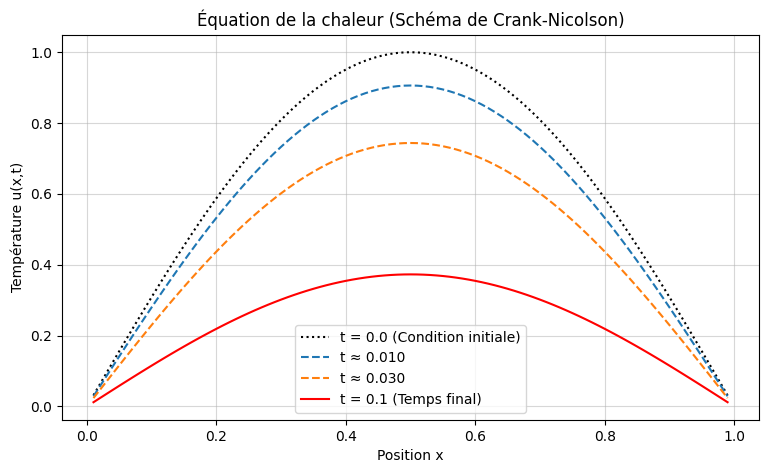

In [22]:
from scipy.sparse import diags, eye, csc_matrix
from scipy.sparse.linalg import spsolve

def crank_nicolson(U0, A, nu, dt, T):
    N = len(U0)
    U = U0.copy()
    t = 0.0

    I = eye(N, format='csc')
    A_sp = csc_matrix(A)

    M_impl = I - (nu * dt / 2) * A_sp
    M_expl = I + (nu * dt / 2) * A_sp
    solutions = [U.copy()]

    while t < T - 1e-12:
        dt_eff = min(dt, T - t)
        if dt_eff != dt:
            M_impl = I - (nu * dt_eff / 2) * A_sp
            M_expl = I + (nu * dt_eff / 2) * A_sp

        rhs = M_expl @ U
        U = spsolve(M_impl, rhs)
        solutions.append(U.copy())
        t += dt_eff
    return solutions

N_pts = 99
dx = 1.0 / (N_pts + 1)
x = np.linspace(dx, 1 - dx, N_pts)
nu = 1.0
dt = 0.005
T_final = 0.1

diagonals = [-2 * np.ones(N_pts), np.ones(N_pts - 1), np.ones(N_pts - 1)]
A = diags(diagonals, [0, -1, 1]).toarray() / dx**2

U0 = np.sin(np.pi * x)
sols = crank_nicolson(U0, A, nu, dt, T_final)

plt.figure(figsize=(9, 5))
plt.plot(x, sols[0], 'k:', label='t = 0.0 (Condition initiale)')
plt.plot(x, sols[int(len(sols)*0.1)], '--', label=f't ≈ {0.1 * T_final:.3f}')
plt.plot(x, sols[int(len(sols)*0.3)], '--', label=f't ≈ {0.3 * T_final:.3f}')
plt.plot(x, sols[-1], 'r-', label=f't = {T_final} (Temps final)')
plt.title('Équation de la chaleur (Schéma de Crank-Nicolson)')
plt.xlabel('Position x')
plt.ylabel('Température u(x,t)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

## TP Noté :Dynamique des Populations

Pour modéliser la propagation d'une maladie, nous avons implémenté une extension du modèle SIR en y ajoutant une quatrième catégorie. Il s'agit du modèle **SEIR**, qui divise la population $N$ en quatre parties :
1. **S (Susceptibles)** : Les individus sains non infectés, vulnérables à la maladie.
2. **E (Exposés)** : Les individus en période d'incubation (contaminés mais pas encore infectieux).
3. **I (Infectés)** : Les individus malades capables de transmettre le pathogène.
4. **R (Rétablis)** : Les individus guéris et immunisés.

Ce système d'équations différentielles ordinaires non-linéaires met en évidence l'importance du traitement numérique (via `scipy.integrate.solve_ivp` par exemple) car il n'admet généralement pas de solution analytique explicite. L'analyse des courbes permet notamment de visualiser le "pic épidémique" et d'évaluer l'impact des paramètres de contagion.

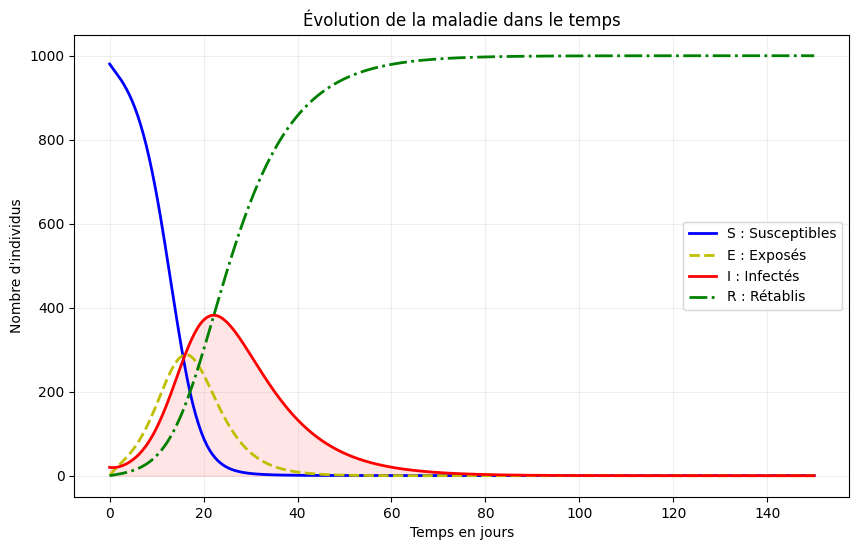

In [24]:
from scipy.integrate import solve_ivp

# Paramètres du modèle épidémiologique SEIR
N = 1000      # Population totale
beta = 0.8    # Taux de transmission
sigma = 0.2   # Taux d'incubation
gamma = 0.1   # Taux de guérison

# Conditions initiales
I0 = 20
E0 = 0
R0 = 0
S0 = N - I0 - E0 - R0
y0 = [S0, E0, I0, R0]

# intervalle temps (150 jours)
t = (0, 150)
t_eval = np.linspace(t[0], t[1], 500)

# Definition du systeme différentiel
def seir_model(t, y):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return [dSdt, dEdt, dIdt, dRdt]

# Resolution numérique avec Runge-Kutta
solution = solve_ivp(seir_model, t, y0, t_eval=t_eval, method='RK45')

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(solution.t, solution.y[0], 'b-', linewidth=2, label='S : Susceptibles')
plt.plot(solution.t, solution.y[1], 'y--', linewidth=2, label='E : Exposés')
plt.plot(solution.t, solution.y[2], 'r-', linewidth=2, label='I : Infectés')
plt.plot(solution.t, solution.y[3], 'g-.', linewidth=2, label='R : Rétablis')
plt.title('Évolution de la maladie dans le temps')
plt.xlabel('Temps en jours')
plt.ylabel('Nombre d\'individus')
plt.grid(True, alpha=0.2)
plt.fill_between(solution.t, solution.y[2], color='red', alpha=0.1)
plt.legend()
plt.show()